<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 30px;
    font-weight: bold;
">
    PhishGuard AI - Data Understanding, Cleaning & Preprocessing
</div>

<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Import library
</div>

In [1]:
# ================== Data & Math ==================
import os
import warnings
import joblib
import numpy as np
import pandas as pd
from urllib.parse import urlparse

# ================== Visualization (only for checking data) ==================
import matplotlib.pyplot as plt
import seaborn as sns

# ================== Preprocessing ==================
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)
sns.set_style('whitegrid')
RANDOM_STATE = 42

<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Function_To_Using
</div>

In [2]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()

    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df

Two small helpers are added for this notebook:

* `get_host(url)` extracts the hostname (without `www.`, port, or `user@` part). We need it to find hosts that appear thousands of times, and later to keep the same host out of both train and test.
* `cleaning_log` records the shape of the data after every cleaning step, so the summary at the end is built from real numbers rather than typed by hand.

In [3]:
def get_host(url):
    """Return the lowercase hostname of a URL without a leading www."""
    parsed = urlparse(url)
    host = parsed.hostname or parsed.netloc
    host = host.lower()
    return host[4:] if host.startswith("www.") else host


cleaning_log = []

def log_step(step, data):
    cleaning_log.append({"Step": step, "Rows": data.shape[0], "Columns": data.shape[1]})

<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Loading the Dataset
</div>

# 3. Loading the Dataset

In [4]:
MERGED_PATH = "merged_features_final.xlsx"
DNS_PATH = "dns_feature_94k.xlsx"

df_raw = pd.read_excel(MERGED_PATH)
dns_raw = pd.read_excel(DNS_PATH)

print("merged_features_final.xlsx :", df_raw.shape)
print("dns_feature_94k.xlsx       :", dns_raw.shape)

merged_features_final.xlsx : (60000, 20)
dns_feature_94k.xlsx       : (94209, 7)


We keep the untouched loaded data in `df_raw` and do all the work on a copy called `df`. If a cleaning step goes wrong, we can always come back to the original.

In [5]:
df = df_raw.copy()
log_step("Raw data loaded", df)
df.head()

,url,entropy,url_length,num_www,ratio_digits_url,num_subdomains,length_hostname,random_domain,num_dots,num_hyphens,ratio_digits_host,prefix_suffix,num_question_mark,num_eq,domain_age,dns_resolvable,num_ips,ttl,num_name_servers,label
0,https://manua.ls,3.500000,16,0,0.000000,0,8,0,1,0,0.0,0,0,0,-1.0,1.0,1.0,3600.0,4.0,legitimate
1,https://t.co/r77VHQx9lP,4.023137,23,0,0.130435,0,4,1,1,0,0.0,0,0,0,5745.0,1.0,1.0,300.0,8.0,phishing
2,https://sites.google.com/view/attyahoo-plus-latest-version,4.145908,58,0,0.000000,1,16,0,2,3,0.0,0,0,0,10351.0,1.0,6.0,300.0,4.0,phishing
3,https://bit.ly/48c5385,3.845351,22,0,0.272727,0,6,0,1,0,0.0,0,0,0,6453.0,1.0,2.0,300.0,8.0,phishing
4,https://strato.de,3.381580,17,0,0.000000,0,9,0,1,0,0.0,0,0,0,-1.0,1.0,1.0,3600.0,4.0,legitimate


In [6]:
df.tail()

,url,entropy,url_length,num_www,ratio_digits_url,num_subdomains,length_hostname,random_domain,num_dots,num_hyphens,ratio_digits_host,prefix_suffix,num_question_mark,num_eq,domain_age,dns_resolvable,num_ips,ttl,num_name_servers,label
59995,https://q-r.to/bfJbhR,3.748995,21,0,0.000000,0,6,1,1,1,0.000000,1,0,0,5100.0,1.0,4.0,60.0,4.0,phishing
59996,https://hometrade-nomura.scd6753.com/?login=kjCYN9GksdMRCAHMVaxn0j2W,5.215636,68,0,0.102941,1,28,1,2,1,0.142857,0,1,1,1416.0,1.0,2.0,300.0,2.0,phishing
59997,https://nimbusweb.me,3.721928,20,0,0.000000,0,12,0,1,0,0.000000,0,0,0,-1.0,1.0,4.0,60.0,4.0,legitimate
59998,https://mhrs.gov.tr,3.471354,19,0,0.000000,0,11,1,2,0,0.000000,0,0,0,5731.0,1.0,1.0,3600.0,4.0,legitimate
59999,https://docs.google.com/presentation/d/e/2PACX-1vQA-KygilZbrT5mtKOkkIlNU-PFq...,5.583470,190,0,0.073684,1,15,0,3,3,0.000000,0,1,4,10352.0,1.0,6.0,300.0,4.0,phishing


<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Understanding the Dataset
</div>

# 4. Understanding the Dataset

## 4.1 What does the dataset represent?

Each **row is one URL**. Columns describe (a) the *shape of the URL text* (lexical features) and (b) what *WHOIS and DNS lookups* say about the domain (network features). The target `label` says whether the URL is a phishing site or a legitimate one.

* **Phishing** URLs (31,641) come from PhishTank, **legitimate** URLs (28,359) from the Tranco top-sites list.
* The goal is to learn patterns that separate them so PhishGuard's Branch A can flag phishing URLs.

## 4.2 Data dictionary (written from the real columns)

> The column table in the reference notebook lists names like `www`, `io`, `th_dom`, `dom_num`, `is_resolvat` that **do not exist** in this file. The table below matches the actual columns.

| Column | Group | Type | Meaning |
| :--- | :--- | :--- | :--- |
| **url** | identifier | text | The full URL. Identifier only - not a model feature |
| **entropy** | lexical | float | Randomness of the URL's characters (Shannon entropy) |
| **url_length** | lexical | int | Number of characters in the URL |
| **num_www** | lexical | int | Number of times `www` appears |
| **ratio_digits_url** | lexical | float | Share of characters in the URL that are digits (0 to 1) |
| **num_subdomains** | lexical | int | Number of subdomains |
| **length_hostname** | lexical | int | Length of the hostname |
| **random_domain** | lexical | binary | 1 if the domain name looks randomly generated |
| **num_dots** | lexical | int | Number of `.` in the **whole URL** |
| **num_hyphens** | lexical | int | Number of `-` in the **whole URL** |
| **ratio_digits_host** | lexical | float | Share of hostname characters that are digits (0 to 1) |
| **prefix_suffix** | lexical | binary | 1 if the domain uses a hyphen prefix/suffix pattern |
| **num_question_mark** | lexical | int | Number of `?` (query string) |
| **num_eq** | lexical | int | Number of `=` (query parameters) |
| **domain_age** | WHOIS | float | Domain age in days. **-1 = unknown** |
| **dns_resolvable** | DNS | binary | 1 if the domain resolved in DNS |
| **num_ips** | DNS | float | Number of IP addresses returned |
| **ttl** | DNS | float | DNS time-to-live in seconds. **-1 = no DNS record** |
| **num_name_servers** | DNS | float | Number of name servers |
| **label** | **target** | text | `phishing` or `legitimate` |

Two details in this table become important later: `-1` in `domain_age` / `ttl` is a placeholder for "unknown", and `num_dots` / `num_hyphens` count over the whole URL (not only the hostname).

## 4.3 How do the two files relate?

Before choosing a file we compare them. If the 94k file simply contained more usable rows, we would prefer it.

In [7]:
in_both = dns_raw['url'].isin(df_raw['url'])
extra_rows = dns_raw[~in_both]
dns_cols = ['domain_age', 'dns_resolvable', 'num_ips', 'ttl', 'num_name_servers']

print("URLs of the 60k file found inside the 94k file :", df_raw['url'].isin(dns_raw['url']).sum(), "of", len(df_raw))
print("Extra rows that exist only in the 94k file     :", len(extra_rows))
print("Columns in the 94k file                        :", list(dns_raw.columns))
print("\nShare of NaN in the DNS columns of the extra rows:")
print(extra_rows[dns_cols].isnull().mean())

URLs of the 60k file found inside the 94k file : 60000 of 60000
Extra rows that exist only in the 94k file     : 34209
Columns in the 94k file                        : ['url', 'label', 'domain_age', 'dns_resolvable', 'num_ips', 'ttl', 'num_name_servers']

Share of NaN in the DNS columns of the extra rows:
domain_age          1.0
dns_resolvable      1.0
num_ips             1.0
ttl                 1.0
num_name_servers    1.0
dtype: float64


**Insight / Observation:**
* Every one of the 60,000 URLs is in the 94k file, so the 94k file is a **superset**.
* The 34,209 extra rows contain **only a URL and a label**. All five DNS/WHOIS columns are 100% empty, and the 94k file has none of the lexical features at all.
* Using them would mean either training on rows with no information or re-extracting all the features ourselves. Re-extraction is feature-extraction work and belongs to a later phase.

**Decision:** continue with `df` = `merged_features_final.xlsx` (60,000 rows x 20 columns). `dns_raw` is not used again.

## 4.4 Column types, unique values, target variable

`data_info` gives a per-column summary (type, most frequent values, unique values, nulls, duplicates).

In [8]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,url,str,"[https://manua.ls, https://t.co/r77VHQx9lP, https://sites.google.com/view/at...",60000,0,0.000000,0
1,entropy,float64,"[3.939470994001288, 4.152391277629867, 4.055958151615124, 3.936260027531527,...",14054,0,0.000000,0
2,url_length,int64,"[22, 21, 23, 20, 19, 18, 17, 24, 175, 16]",454,0,0.000000,0
3,num_www,int64,"[0, 1, 2, 3]",4,0,0.000000,0
4,ratio_digits_url,float64,"[0.0, 0.0454545454545454, 0.0909090909090909, 0.0476190476190476, 0.04347826...",2081,0,0.000000,0
5,num_subdomains,int64,"[0, 1, 2, 3, 4, 6, 5, 7]",8,0,0.000000,0
6,length_hostname,int64,"[15, 6, 11, 12, 7, 13, 10, 8, 14, 16]",79,0,0.000000,0
7,random_domain,int64,"[0, 1]",2,0,0.000000,0
8,num_dots,int64,"[1, 2, 3, 4, 5, 6, 13, 7, 10, 8]",18,0,0.000000,0
9,num_hyphens,int64,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 10]",28,0,0.000000,0


In [9]:
print("Rows, columns :", df.shape)
print("\nData types:")
print(df.dtypes.value_counts())
print("\nCategorical / text columns :", df.select_dtypes(exclude='number').columns.tolist())
print("Numerical columns          :", df.select_dtypes(include='number').columns.tolist())

Rows, columns : (60000, 20)

Data types:
int64      10
float64     8
str         2
Name: count, dtype: int64

Categorical / text columns : ['url', 'label']
Numerical columns          : ['entropy', 'url_length', 'num_www', 'ratio_digits_url', 'num_subdomains', 'length_hostname', 'random_domain', 'num_dots', 'num_hyphens', 'ratio_digits_host', 'prefix_suffix', 'num_question_mark', 'num_eq', 'domain_age', 'dns_resolvable', 'num_ips', 'ttl', 'num_name_servers']


**Insight / Observation:**
* 20 columns: `url` and `label` are text, the other **18 are numeric** and are our candidate features.
* `url` has 60,000 unique values, so it is an identifier and cannot be used by a model directly.
* `label` is the **target** with two classes. It is text, so it must be encoded to 0/1 later.
* `random_domain` and `prefix_suffix` hold only 0/1, and `dns_resolvable` is stored as float only because it contains NaN. These are really binary.
* `domain_age`, `dns_resolvable`, `num_ips`, `ttl`, `num_name_servers` have 2 nulls each. Other missing values are hidden (see Section 6).

<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Initial Data Inspection
</div>

# 5. Initial Data Inspection

## 5.1 Summary statistics

Statistics help us spot impossible values (negative counts, ratios above 1) and very skewed columns.

In [10]:
df.describe().T.style.bar(subset=['mean'], color='#FFA07A').background_gradient(
    subset=['std', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '12pt', 'border': '1.5px solid black'}).set_caption("Summary Statistics of the Dataset")

,count,mean,std,min,25%,50%,75%,max
entropy,60000.000000,4.072082,0.563020,2.353338,3.719295,3.936260,4.222208,6.032729
url_length,60000.000000,44.119367,117.729571,12.000000,21.000000,24.000000,41.000000,25523.000000
num_www,60000.000000,0.097650,0.298746,0.000000,0.000000,0.000000,0.000000,3.000000
ratio_digits_url,60000.000000,0.045301,0.084466,0.000000,0.000000,0.000000,0.067797,0.826087
num_subdomains,60000.000000,0.481783,0.576923,0.000000,0.000000,0.000000,1.000000,7.000000
length_hostname,60000.000000,16.661200,10.369705,4.000000,10.000000,15.000000,20.000000,100.000000
random_domain,60000.000000,0.148483,0.355581,0.000000,0.000000,0.000000,0.000000,1.000000
num_dots,60000.000000,1.669483,0.975325,1.000000,1.000000,2.000000,2.000000,23.000000
num_hyphens,60000.000000,0.473500,1.102173,0.000000,0.000000,0.000000,1.000000,50.000000
ratio_digits_host,60000.000000,0.033072,0.103449,0.000000,0.000000,0.000000,0.000000,0.800000


**Insight / Observation:**
* `url_length` has median 24 but max **25,523** - an extremely long tail.
* `domain_age` and `ttl` have a **minimum of -1**. A negative age is impossible, so -1 must be a placeholder.
* Ratios stay inside 0 to 1, and the counts are never negative.
* More than 30% of `domain_age` values are -1, so its 25th percentile is -1 and the raw mean is pulled down by placeholders.

## 5.2 Target variable

In [11]:
print("Target Variable counts:")
print(df['label'].value_counts())
print()
print(df['label'].value_counts(normalize=True).round(3))

Target Variable counts:
label
phishing      31641
legitimate    28359
Name: count, dtype: int64

label
phishing      0.527
legitimate    0.473
Name: proportion, dtype: float64


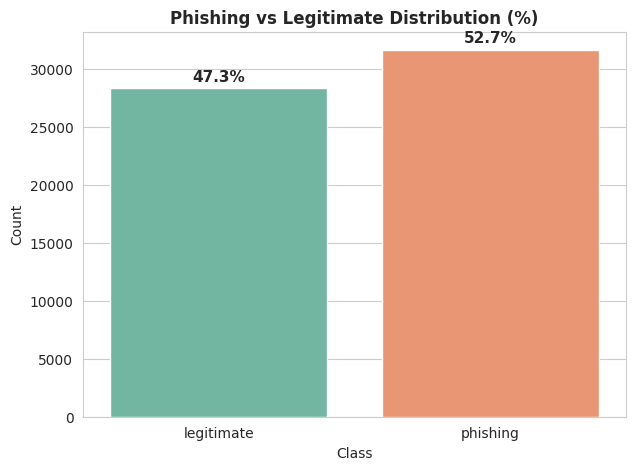

In [12]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='label', hue='label', palette='Set2', legend=False)
plt.title('Phishing vs Legitimate Distribution (%)', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=10)
plt.ylabel('Count', fontsize=10)
total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height / total * 100:.1f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=11, fontweight='bold',
                    xytext=(0, 3), textcoords='offset points')
plt.show()

**Insight / Observation:**
* 52.7% phishing vs 47.3% legitimate - nearly balanced, so **no resampling (SMOTE, class weights) is needed**.
* We will still use a *stratified* split later so both classes keep this ratio in train and test.

<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Data Quality Checks
</div>

# 6. Data Quality Checks

Here we only **detect** problems. Fixing happens in Section 7.

## 6.1 Missing values (real NaN)

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].to_frame('missing_count')
missing['percent'] = (missing['missing_count'] / len(df) * 100).round(4)
display(missing)

print("Rows that contain a NaN:")
df[df.isnull().any(axis=1)]

,missing_count,percent
domain_age,2,0.0033
dns_resolvable,2,0.0033
num_ips,2,0.0033
ttl,2,0.0033
num_name_servers,2,0.0033


Rows that contain a NaN:


,url,entropy,url_length,num_www,ratio_digits_url,num_subdomains,length_hostname,random_domain,num_dots,num_hyphens,ratio_digits_host,prefix_suffix,num_question_mark,num_eq,domain_age,dns_resolvable,num_ips,ttl,num_name_servers,label
5000,https://valerieann1990.wixsite.com/my-site,4.356370,42,0,0.095238,1,26,0,2,1,0.153846,0,0,0,NaN,NaN,NaN,NaN,NaN,phishing
10000,https://q-r.to/bfSIL7,3.939471,21,0,0.047619,0,6,1,1,1,0.000000,1,0,0,NaN,NaN,NaN,NaN,NaN,phishing


**Insight / Observation:**
* Only **2 rows** (index 5000 and 10000, both phishing) have NaN, and they are missing all five DNS/WHOIS features together. That means the lookup for those URLs failed completely.
* This is 0.003% of the data.

## 6.2 Hidden missing values (sentinel `-1`)

A NaN is at least visible. A placeholder such as `-1` is dangerous because pandas and models treat it as a real number.

In [14]:
sentinel = pd.DataFrame({
    'rows_with_-1': [(df['domain_age'] == -1).sum(), (df['ttl'] == -1).sum()],
    'percent': [(df['domain_age'] == -1).mean() * 100, (df['ttl'] == -1).mean() * 100],
}, index=['domain_age', 'ttl']).round(2)
display(sentinel)

print("Share of -1 in domain_age by class:")
print((df['domain_age'] == -1).groupby(df['label']).mean().round(3))

print("\nIs ttl == -1 exactly the same rows as dns_resolvable == 0 ?")
valid = df['dns_resolvable'].notnull()
print(((df.loc[valid, 'ttl'] == -1) == (df.loc[valid, 'dns_resolvable'] == 0)).all())

print("\nWhen dns_resolvable == 0, the other DNS columns are:")
print(df.loc[df['dns_resolvable'] == 0, ['num_ips', 'ttl', 'num_name_servers']].agg(['min', 'max']))

,rows_with_-1,percent
domain_age,18677,31.13
ttl,4174,6.96


Share of -1 in domain_age by class:
label
legitimate    0.231
phishing      0.383
Name: domain_age, dtype: float64

Is ttl == -1 exactly the same rows as dns_resolvable == 0 ?
True

When dns_resolvable == 0, the other DNS columns are:
     num_ips  ttl  num_name_servers
min      0.0 -1.0               0.0
max      0.0 -1.0               0.0


**Insight / Observation:**
* `domain_age = -1` in **18,677 rows (31%)** - the WHOIS/RDAP lookup returned no age (for example some country-code domains do not publish it).
* The unknown rate differs by class: **38% of phishing vs 23% of legitimate**. So "age unknown" is itself informative and we must not throw that information away when we fix it.
* `ttl = -1` happens in **exactly the 4,174 rows where `dns_resolvable = 0`**, together with `num_ips = 0` and `num_name_servers = 0`. Those rows have no DNS record at all, so a TTL simply does not exist.

## 6.3 Duplicates

Exact duplicate rows are easy to find. But the same URL can appear in slightly different forms (upper/lower case, trailing `/`), so we also test a normalised version.

In [15]:
print("Exact duplicate rows      :", df.duplicated().sum())
print("Duplicate URL strings     :", df['url'].duplicated().sum())

df_check = df.assign(url_norm=df['url'].str.lower().str.rstrip('/'))
dup_groups = df_check[df_check['url_norm'].duplicated(keep=False)]
print("Duplicate URLs after normalising (lowercase, no trailing '/') :", df_check['url_norm'].duplicated().sum())
print("Rows involved in those duplicate groups                     :", len(dup_groups))

labels_per_url = dup_groups.groupby('url_norm')['label'].nunique()
conflicts = labels_per_url[labels_per_url > 1].index
print("Duplicate groups whose two rows have DIFFERENT labels       :", len(conflicts))
dup_groups[dup_groups['url_norm'].isin(conflicts)][['url', 'label', 'domain_age', 'url_length']]

Exact duplicate rows      : 0
Duplicate URL strings     : 0
Duplicate URLs after normalising (lowercase, no trailing '/') : 151
Rows involved in those duplicate groups                     : 302
Duplicate groups whose two rows have DIFFERENT labels       : 2


,url,label,domain_age,url_length
5595,https://kakaku.com,legitimate,10055.0,18
20437,https://kakaku.com/,phishing,10055.0,19
27791,https://www.art.com,legitimate,9916.0,19
49714,https://www.art.com/,phishing,9917.0,20


**Insight / Observation:**
* No exact duplicates, but there are **151 URLs that appear twice** (e.g. `http://allegro.639041.shop` and `http://allegro.639041.shop/`). They are the same page collected in two forms. Their feature values differ slightly (length +1, `domain_age` sometimes changes by a day) so `df.duplicated()` cannot see them.
* **2 of those pairs carry conflicting labels**: `kakaku.com` and `www.art.com` are once `legitimate` and once `phishing`. One of the two labels must be wrong, and we cannot tell which from the data.
* Duplicates matter because the same page could land in both train and test, and the model would be rewarded for memorising instead of generalising.

## 6.4 Invalid or impossible values

We test rules that must be true for a valid row.

In [16]:
binary_check = {c: sorted(df[c].dropna().unique().tolist()) for c in ['random_domain', 'prefix_suffix', 'dns_resolvable']}
print("Values in binary columns:", binary_check)

count_cols = ['url_length', 'num_www', 'num_subdomains', 'length_hostname', 'num_dots', 'num_hyphens',
              'num_question_mark', 'num_eq', 'num_ips', 'num_name_servers']
print("\nNegative values in count columns :", int((df[count_cols] < 0).sum().sum()))
print("Ratios outside [0, 1]            :", int(((df[['ratio_digits_url', 'ratio_digits_host']] < 0) |
                                                (df[['ratio_digits_url', 'ratio_digits_host']] > 1)).sum().sum()))
print("domain_age values below -1       :", int((df['domain_age'] < -1).sum()))
print("ttl values below -1              :", int((df['ttl'] < -1).sum()))
print("Constant columns                 :", [c for c in df.columns if df[c].nunique() <= 1])

Values in binary columns: {'random_domain': [0, 1], 'prefix_suffix': [0, 1], 'dns_resolvable': [0.0, 1.0]}

Negative values in count columns : 0
Ratios outside [0, 1]            : 0
domain_age values below -1       : 0
ttl values below -1              : 0
Constant columns                 : []


**Insight / Observation:**
* Binary columns contain only 0/1, no count or ratio is out of range, and no column is constant. The only "invalid" values are the deliberate `-1` placeholders already found in 6.2.

## 6.5 Consistency: do the features match the URL text?

Because the features were computed from the URL, we can re-compute a few and compare. A mismatch means the row is corrupted.

In [17]:
host_series = df['url'].map(get_host)
consistency = pd.Series({
    "url_length == len(url)": (df['url_length'] == df['url'].str.len()).mean(),
    "num_dots == count of '.' in URL": (df['num_dots'] == df['url'].str.count(r'\.')).mean(),
    "num_hyphens == count of '-' in URL": (df['num_hyphens'] == df['url'].str.count('-')).mean(),
    "num_question_mark == count of '?'": (df['num_question_mark'] == df['url'].str.count(r'\?')).mean(),
    "num_eq == count of '='": (df['num_eq'] == df['url'].str.count('=')).mean(),
}).to_frame('match_rate')
display(consistency.style.format('{:.4%}'))

bad_len = df[df['url_length'] != df['url'].str.len()]
print("Rows where url_length != len(url):", len(bad_len), "| labels:", bad_len['label'].value_counts().to_dict())
bad_len.assign(real_len=bad_len['url'].str.len())[['url', 'url_length', 'real_len']].head(7)

,match_rate
url_length == len(url),99.9883%
num_dots == count of '.' in URL,100.0000%
num_hyphens == count of '-' in URL,100.0000%
num_question_mark == count of '?',100.0000%
num_eq == count of '=',100.0000%


Rows where url_length != len(url): 7 | labels: {'phishing': 7}


,url,url_length,real_len
2504,https://ufggfj.nh1do.cyou/Ã°ÂÂÂ¢Ã°ÂÂÂ§Ã°ÂÂÂÃ°ÂÂÅ¾Ã°ÂÂÂ±.Ã°ÂÂÂ¡Ã...,63,99
8460,https://wwfhlegxmjlizkasutzhixk.comâˆ•wwfhlegxmjlizkasutzhixkâˆ•wwfhlegxmjli...,148,154
11843,https://slfsxmmmkfkehkubgxmriafi.comâˆ•slfsxmmmkfkehkubgxmriafiâˆ•slfsxmmmkf...,148,154
17912,https://cjkmmigeqxvjuwxjtcrorrafl.comâˆ•cjkmmigeqxvjuwxjtcrorraflâˆ•cjkmmige...,156,162
28686,https://oemihhgavtsddphiwlsqxqgk.comâˆ•oemihhgavtsddphiwlsqxqgkâˆ•oemihhgavt...,151,157
33930,https://duso.artmosaicstudio.shop/fclkv2/ch-de-dpp/?aff_id=push_aff_id&amp;a...,609,611
39903,https://cheesetherapy.com.auâˆ•VagmFnqYâˆ•fdVWorsmAâˆ•Rbvsxol@8899382712.668...,89,95


**Insight / Observation:**
* `num_dots`, `num_hyphens`, `num_question_mark` and `num_eq` match the URL text in 100% of rows, which also confirms they count over the **whole URL**, not only the hostname.
* **7 rows** (all phishing) have a `url_length` different from `len(url)`. Their URL text contains garbled characters (encoding damage such as `Ã°Â...` and `âˆ•`). The stored `url_length` came from the original text, so the **numeric features are still right; only the `url` string is damaged**.

## 6.6 Data leakage and structural shortcuts

Leakage means a feature gives the answer for a reason that will not exist in real use. There is no feature here derived from the label (unlike PhiUSIIL), but the *way the two classes were collected* creates a shortcut. We measure it without training any model.

In [18]:
parsed = df['url'].map(urlparse)
shape = pd.DataFrame({
    'label': df['label'],
    'has_path': parsed.map(lambda p: len(p.path) > 1),
    'has_query': parsed.map(lambda p: len(p.query) > 0),
    'ends_with_slash': df['url'].str.endswith('/'),
    'is_http': df['url'].str.startswith('http://'),
})
print("Share of URLs with each property, by class:")
display(shape.groupby('label').mean().round(3).T)

print("Legitimate rows with '?' in URL :", int(((df['label'] == 'legitimate') & (df['num_question_mark'] > 0)).sum()))
print("Legitimate rows with '=' in URL :", int(((df['label'] == 'legitimate') & (df['num_eq'] > 0)).sum()))
print("Max url_length by class:")
print(df.groupby('label')['url_length'].max())

Share of URLs with each property, by class:


label,legitimate,phishing
has_path,0.0,0.665
has_query,0.0,0.201
ends_with_slash,0.0,0.306
is_http,0.0,0.056


Legitimate rows with '?' in URL : 0
Legitimate rows with '=' in URL : 0
Max url_length by class:
label
legitimate       49
phishing      25523
Name: url_length, dtype: int64


**Insight / Observation:**
* **100% of legitimate URLs are bare homepages**: no path, no query, no trailing `/`, always `https`. Among phishing URLs, about 66% have a path, and **9,680 end with `/`** while **zero** legitimate URLs do.
* Legitimate rows have `num_question_mark = 0` and `num_eq = 0` **without exception**, so these two features act as a deterministic "phishing" flag. The longest legitimate URL is 49 characters vs 25,523 for phishing.
* Reason: the legitimate class was built from Tranco *domains* (homepages only), while phishing URLs come from PhishTank *reports* (full links). A model can reach high accuracy by learning "has a path means phishing", which is not real phishing detection. On real browsing, legitimate pages have paths like `/login` or `?id=5`, so it would misfire.
* **This is a collection bias. Cleaning cannot remove it.** We handle it in Section 7.7 and report it honestly in the summary.

## 6.7 Does `domain_age` describe the site or the platform?

Many phishing URLs are hosted on big shared platforms. WHOIS for `docs.google.com` returns Google's age, not the phisher's page.

In [19]:
host_df = df.assign(host=host_series)
top_hosts = host_df['host'].value_counts().head(8).index

shared = host_df[host_df['host'].isin(top_hosts)].groupby('host').agg(
    rows=('url', 'size'),
    phishing_share=('label', lambda s: (s == 'phishing').mean()),
    distinct_domain_ages=('domain_age', 'nunique'),
    most_common_age=('domain_age', lambda s: s.mode().iat[0]),
).sort_values('rows', ascending=False)
display(shared.round(2))

print("Unique hosts in the dataset:", host_df['host'].nunique())
print("Share of ALL rows coming from these 8 hosts:", round(host_df['host'].isin(top_hosts).mean(), 3))
print("Share of PHISHING rows from these 8 hosts  :", round(host_df.loc[host_df['label'] == 'phishing', 'host'].isin(top_hosts).mean(), 3))

,rows,phishing_share,distinct_domain_ages,most_common_age
host,,,,
docs.google.com,3928,1.0,3,10351.0
qrco.de,1619,1.0,1,-1.0
bit.ly,1485,1.0,3,6453.0
q-r.to,1310,1.0,3,5099.0
l.ead.me,1240,1.0,1,-1.0
new.express.adobe.com,708,1.0,3,14306.0
sites.google.com,653,1.0,3,10351.0
dropbox.com,379,1.0,3,11161.0


Unique hosts in the dataset: 40893
Share of ALL rows coming from these 8 hosts: 0.189
Share of PHISHING rows from these 8 hosts  : 0.358


**Insight / Observation:**
* `docs.google.com` alone gives **3,928 rows with only 3 distinct ages** (about 10,351 days = Google's age). `bit.ly`, `sites.google.com`, `new.express.adobe.com` and `dropbox.com` show the same pattern, and `qrco.de` / `l.ead.me` are *always* `-1`.
* For these rows `domain_age` describes the *platform* (or is unknown), not the phishing page. This is the same free-hosting inheritance problem found earlier in the team's own RDAP pipeline.
* These 8 hosts are **100% phishing** and make up **18.9% of all rows and 35.8% of the phishing rows**, so many rows are near-identical in `domain_age`, `ttl`, `num_ips`, `num_name_servers`. The host itself is almost a label.
* We **cannot repair** this without new lookups. We document it, and it changes how we split the data (Section 8.3): rows from the same host must not sit on both sides of the train/test split.

## 6.8 Outliers

In [20]:
print(df['url_length'].describe(percentiles=[.5, .9, .99, .999]).round(1))
long_urls = df[df['url_length'] > 1000]
print("\nURLs longer than 1000 characters:", len(long_urls), "| labels:", long_urls['label'].value_counts().to_dict())
print("Longest hostname:", df['length_hostname'].max(), "characters")
print("\nSkewness of the numeric columns (|skew| > 2 means a heavy tail):")
df.select_dtypes(include='number').skew().round(1).sort_values(ascending=False).head(10)

count    60000.0
mean        44.1
std        117.7
min         12.0
50%         24.0
90%         84.0
99%        200.0
99.9%      557.0
max      25523.0
Name: url_length, dtype: float64

URLs longer than 1000 characters: 21 | labels: {'phishing': 21}
Longest hostname: 100 characters

Skewness of the numeric columns (|skew| > 2 means a heavy tail):


url_length           169.6
num_eq                11.9
num_hyphens            7.0
num_dots               5.0
ratio_digits_host      4.0
num_question_mark      3.4
ttl                    3.2
prefix_suffix          2.9
num_www                2.8
ratio_digits_url       2.5
dtype: float64

**Insight / Observation:**
* 99% of URLs are below 200 characters, but 21 phishing URLs pass 1,000. Long, junk-filled links are a **real phishing behaviour**, not a typing error, so these are *genuine* outliers.
* Skewness is extreme for `url_length` (about 170), `num_eq`, `num_hyphens`, `num_dots`.
* Deleting these rows would remove real phishing behaviour. We will **keep them and reduce their influence with a log transform** (Section 8.4).

## 6.9 Summary of the problems found

| # | Problem | Size | Decision (Section 7) |
| :-: | :--- | :--- | :--- |
| 1 | Rows with NaN in all DNS/WHOIS columns | 2 rows | Drop |
| 2 | Duplicate URLs in different forms | 151 pairs (2 with conflicting labels) | Drop duplicates; drop both rows of conflicting pairs |
| 3 | `domain_age = -1` used as "unknown" | 18,677 rows | Convert to NaN + keep an "unknown" flag |
| 4 | `ttl = -1` = no DNS record | 4,174 rows | Convert to NaN (flag already exists as `dns_resolvable`) |
| 5 | Wrong dtypes (binary/count stored as float) | 3 columns | Convert to int |
| 6 | Garbled URL text | 7 rows | Keep (features are correct), document |
| 7 | Extreme outliers (`url_length` up to 25,523) | 21 rows > 1000 | Keep, handle with log transform later |
| 8 | Structural shortcut (bare homepages vs full links) | whole dataset | Cannot clean; flag features, provide drop switch |
| 9 | `domain_age` reflects platform for shared hosts | thousands of rows | Cannot repair; document; group-aware split |

<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Data Cleaning
</div>

# 7. Data Cleaning

Each step follows the same pattern: **problem -> why it matters -> options -> decision -> apply -> before/after**.

## 7.1 Missing values (2 rows)

**Problem:** 2 rows have NaN in all five DNS/WHOIS columns.

**Why it matters:** most sklearn models cannot handle NaN and will raise an error.

**Options:**
1. Impute the 5 columns (median / mode). But there is no partial information to build on: all five are missing together, so we would be inventing a whole DNS profile.
2. Treat them as "unresolvable" (`dns_resolvable = 0`). That is a guess about why the lookup failed.
3. **Drop the rows.**

**Decision:** drop. It is 0.003% of the data, so nothing is lost, and we avoid making up values.

In [21]:
before = df.shape
print("Before:", before, "| NaN cells:", int(df.isnull().sum().sum()))

df = df.dropna().reset_index(drop=True)

print("After :", df.shape, "| NaN cells:", int(df.isnull().sum().sum()))
print("Class counts now:", df['label'].value_counts().to_dict())
log_step("Dropped 2 rows with NaN", df)

Before: (60000, 20) | NaN cells: 10
After : (59998, 20) | NaN cells: 0
Class counts now: {'phishing': 31639, 'legitimate': 28359}


## 7.2 Duplicates

**Problem:** 151 URLs occur twice in slightly different forms, 2 of them with conflicting labels.

**Why it matters:** duplicates give the model the same example twice, and if one copy is in train and one in test, the test score is inflated. A conflicting pair teaches the model two opposite answers for the same page.

**Options:**
* Keep everything - leaves the inflation and the contradictions.
* Keep the first copy of each duplicate - fine when both copies have the same label.
* For conflicting pairs: keep the one we "believe", or drop both.

**Decision:**
* Normalise the URL (lowercase, no trailing `/`) and keep the **first** copy of each non-conflicting duplicate.
* **Drop both rows** of the 2 conflicting pairs. We have no evidence that says which label is right, and 4 rows out of 60,000 are cheap to lose.

In [22]:
df['url_norm'] = df['url'].str.lower().str.rstrip('/')

labels_per_url = df.groupby('url_norm')['label'].nunique()
conflict_urls = labels_per_url[labels_per_url > 1].index

print("Before:", df.shape)
print("Conflicting URLs to drop completely:", list(conflict_urls))

df = df[~df['url_norm'].isin(conflict_urls)]
df = df.drop_duplicates(subset='url_norm', keep='first')
df = df.drop(columns='url_norm').reset_index(drop=True)

print("After :", df.shape)
print("Remaining duplicate URLs after normalising:", df['url'].str.lower().str.rstrip('/').duplicated().sum())
print("Class counts now:", df['label'].value_counts().to_dict())
log_step("Removed duplicate URLs (149) and conflicting pairs (4 rows)", df)

Before: (59998, 21)
Conflicting URLs to drop completely: ['https://kakaku.com', 'https://www.art.com']


After : (59845, 20)


Remaining duplicate URLs after normalising: 0
Class counts now: {'phishing': 31488, 'legitimate': 28357}


**Result:** 153 rows removed (149 duplicate copies + 4 rows from the 2 conflicting pairs). The remaining data has one row per URL and no contradicting labels.

## 7.3 Placeholder `-1` in `domain_age` and `ttl`

**Problem:** `-1` means "unknown" but is stored as a number.

**Why it matters:**
* For any distance/linear model, `-1` says "younger than a brand new domain", which is meaningless, and it pulls the mean, the standard deviation and the scaling.
* It affects 31% of `domain_age`.

**Options:**
1. Leave `-1` - tree models can cope, but the meaning stays wrong and other models suffer.
2. Convert to NaN and impute the median - clean, but hides the fact that the value was unknown.
3. **Convert to NaN, add an "unknown" flag, impute later inside the pipeline.**

**Decision:**
* `domain_age`: convert to NaN **and** add `domain_age_unknown` (1/0). Section 6.2 showed that unknown is more common for phishing (38% vs 23%), so the flag carries real signal. This is missing-value handling, not feature engineering: we preserve information the placeholder was already holding.
* `ttl`: convert to NaN. No new flag is needed because `ttl = -1` is exactly `dns_resolvable = 0`, so that column already says it.
* **The imputation itself is done later inside the pipeline (Section 8.5)**, fitted on the training set only, so the median is not learned from the test set.

In [23]:
print("BEFORE")
print(df[['domain_age', 'ttl']].describe().loc[['count', 'mean', 'min', '50%']].round(1))
print("Rows with -1: domain_age =", int((df['domain_age'] == -1).sum()), "| ttl =", int((df['ttl'] == -1).sum()))

df['domain_age_unknown'] = (df['domain_age'] == -1).astype(int)
df['domain_age'] = df['domain_age'].replace(-1, np.nan)
df['ttl'] = df['ttl'].replace(-1, np.nan)

print("\nAFTER")
print(df[['domain_age', 'ttl']].describe().loc[['count', 'mean', 'min', '50%']].round(1))
print("NaN: domain_age =", int(df['domain_age'].isnull().sum()), "| ttl =", int(df['ttl'].isnull().sum()))
print("domain_age_unknown value counts:", df['domain_age_unknown'].value_counts().to_dict())
log_step("Replaced -1 by NaN (domain_age, ttl) + added domain_age_unknown", df)

BEFORE
       domain_age      ttl
count     59845.0  59845.0
mean       4616.6   2018.8
min          -1.0     -1.0
50%        4555.0    300.0
Rows with -1: domain_age = 18626 | ttl = 4141

AFTER
       domain_age      ttl
count     41219.0  55704.0
mean       6703.2   2169.0
min           1.0      0.0
50%        6953.0    300.0
NaN: domain_age = 18626 | ttl = 4141
domain_age_unknown value counts: {0: 41219, 1: 18626}


**Result:** `domain_age` now has a real minimum (1 day) and a higher, honest mean, and `ttl` has a real minimum too. The unknowns are true NaN values that we will impute inside the pipeline, and `domain_age_unknown` keeps the "was unknown" information.

## 7.4 Data types

**Problem:** `dns_resolvable`, `num_ips` and `num_name_servers` are stored as float only because NaN was present. After 7.1 they are whole numbers.

**Why it matters:** correct dtypes save memory, avoid confusing `1.0` with a continuous value, and make the intent of the column clear (`dns_resolvable` is a yes/no flag).

**Decision:** convert these three to `int`. `ttl` and `domain_age` stay float because they now legitimately contain NaN.

In [24]:
print("BEFORE")
print(df[['dns_resolvable', 'num_ips', 'num_name_servers']].dtypes)

df[['dns_resolvable', 'num_ips', 'num_name_servers']] = df[['dns_resolvable', 'num_ips', 'num_name_servers']].astype(int)

print("\nAFTER")
print(df[['dns_resolvable', 'num_ips', 'num_name_servers']].dtypes)
log_step("Converted 3 float columns to int", df)

BEFORE
dns_resolvable      float64
num_ips             float64
num_name_servers    float64
dtype: object

AFTER
dns_resolvable      int64
num_ips             int64
num_name_servers    int64
dtype: object


## 7.5 Re-validating the rules

After changing values we test again that nothing became invalid.

In [25]:
count_cols = ['url_length', 'num_www', 'num_subdomains', 'length_hostname', 'num_dots', 'num_hyphens',
              'num_question_mark', 'num_eq', 'num_ips', 'num_name_servers']
checks = {
    "No negative counts": bool((df[count_cols] >= 0).all().all()),
    "domain_age > 0 where known": bool((df['domain_age'].dropna() > 0).all()),
    "ttl >= 0 where known": bool((df['ttl'].dropna() >= 0).all()),
    "ratios inside [0, 1]": bool(df[['ratio_digits_url', 'ratio_digits_host']].apply(lambda s: s.between(0, 1)).all().all()),
    "binary columns only 0/1": bool(df[['random_domain', 'prefix_suffix', 'dns_resolvable', 'domain_age_unknown']].isin([0, 1]).all().all()),
    "ttl is NaN exactly when dns_resolvable == 0": bool((df['ttl'].isnull() == (df['dns_resolvable'] == 0)).all()),
    "no exact duplicate rows": bool(df.duplicated().sum() == 0),
}
pd.Series(checks, name="passed").to_frame()

,passed
No negative counts,True
domain_age > 0 where known,True
ttl >= 0 where known,True
"ratios inside [0, 1]",True
binary columns only 0/1,True
ttl is NaN exactly when dns_resolvable == 0,True
no exact duplicate rows,True


## 7.6 Garbled URL text (7 rows) and outliers

**Garbled URLs.** The 7 rows with encoding damage still have correct numeric features, because those were computed from the original text. `url` is never given to the model as a feature.
* *Options:* drop the 7 rows, or try to repair the text, or keep them.
* **Decision: keep.** Dropping would lose valid rows for a problem that does not touch any feature. We keep the row but should not rely on their URL text if we later extract new features from it.

**Outliers.** We checked in 6.8 that URLs up to 25,523 characters are real phishing behaviour.
* *Options:* delete, clip (winsorize), transform, or keep.
* **Decision: keep them in the cleaned dataset.** Deleting removes real signal, and clipping would erase the exact behaviour (very long links) that identifies phishing. Their effect on scaling is reduced in Section 8.4 with a log transform, which leaves the rows and their ordering intact.

## 7.7 The structural shortcut (leakage-like features)

**Problem:** `num_question_mark` and `num_eq` are `0` for **every** legitimate row (Section 6.6). Any model will discover "value above 0 means phishing".

**Why it matters:** the score would say the model detects phishing, when it partly detects "this is a full link, not a bare homepage". On real pages, this would produce false alarms on ordinary legitimate URLs with a query string.

**Options:**
1. **Keep, flag, and evaluate on independent data.** Nothing is removed; the team's own fresh URLs (bare + full links on both sides) become the honest test.
2. **Drop the two deterministic features** (`num_question_mark`, `num_eq`). More honest, but the model also loses some real information.
3. Rebuild the legitimate class with URLs that have paths. This is the true fix but it needs new data collection.

**Decision:** option 1 by default, with a switch for option 2. `url_length` and `entropy` are softer versions of the same shortcut, and they are *not* dropped here because they also carry legitimate signal (that judgement belongs in the next phase).

In [26]:
SHORTCUT_FEATURES = ['num_question_mark', 'num_eq']
DROP_SHORTCUT_FEATURES = False

if DROP_SHORTCUT_FEATURES:
    df = df.drop(columns=SHORTCUT_FEATURES)
    log_step("Dropped shortcut features", df)

print("Drop shortcut features:", DROP_SHORTCUT_FEATURES)
print("Columns:", df.shape[1])

Drop shortcut features: False
Columns: 21


## 7.8 Save the cleaned dataset

This file still has the `url` and text `label`, has not been scaled, and is the version tree models (XGBoost) can use directly.

In [27]:
os.makedirs("output", exist_ok=True)
df.to_csv("output/cleaned_dataset.csv", index=False)
print("Saved output/cleaned_dataset.csv", df.shape)
df.head()

Saved output/cleaned_dataset.csv (59845, 21)


,url,entropy,url_length,num_www,ratio_digits_url,num_subdomains,length_hostname,random_domain,num_dots,num_hyphens,ratio_digits_host,prefix_suffix,num_question_mark,num_eq,domain_age,dns_resolvable,num_ips,ttl,num_name_servers,label,domain_age_unknown
0,https://manua.ls,3.500000,16,0,0.000000,0,8,0,1,0,0.0,0,0,0,NaN,1,1,3600.0,4,legitimate,1
1,https://t.co/r77VHQx9lP,4.023137,23,0,0.130435,0,4,1,1,0,0.0,0,0,0,5745.0,1,1,300.0,8,phishing,0
2,https://sites.google.com/view/attyahoo-plus-latest-version,4.145908,58,0,0.000000,1,16,0,2,3,0.0,0,0,0,10351.0,1,6,300.0,4,phishing,0
3,https://bit.ly/48c5385,3.845351,22,0,0.272727,0,6,0,1,0,0.0,0,0,0,6453.0,1,2,300.0,8,phishing,0
4,https://strato.de,3.381580,17,0,0.000000,0,9,0,1,0,0.0,0,0,0,NaN,1,1,3600.0,4,legitimate,1


<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Data Preprocessing
</div>

# 8. Data Preprocessing

The cleaned data is now turned into something ML-ready. The order matters: **encode target -> separate X/y -> split -> fit transformations on train only -> apply to test**. Any statistic learned from the test set (median, mean, std) would leak information from the exam into the training.

## 8.1 Encoding the target

**What:** convert `label` text to numbers.
**Why:** models need numeric targets.
**Choice:** manual mapping `phishing = 1`, `legitimate = 0`. With only two known classes, `LabelEncoder` would assign 0/1 alphabetically (`legitimate=0`, `phishing=1`), which happens to be the same, but an explicit mapping is clearer and guarantees **phishing is the positive class** (so precision/recall later refer to phishing). This is also the project's convention, and the opposite of the PhiUSIIL dataset.

In [28]:
print("BEFORE:", df['label'].unique().tolist())
y = df['label'].map({'legitimate': 0, 'phishing': 1}).rename('target')
print("AFTER :", sorted(y.unique().tolist()))
print(y.value_counts().rename({0: 'legitimate (0)', 1: 'phishing (1)'}))

BEFORE: ['legitimate', 'phishing']
AFTER : [0, 1]
target
phishing (1)      31488
legitimate (0)    28357
Name: count, dtype: int64


## 8.2 Separating features and target

`url` is an identifier, so it leaves the feature matrix. Before we remove it we compute the `host` of each URL and keep it separately as a **grouping key** for the split. `label` is replaced by `target`.

In [29]:
groups = df['url'].map(get_host).rename('host')
X = df.drop(columns=['url', 'label'])

print("X shape:", X.shape, "| y shape:", y.shape)
print("Feature columns:", X.columns.tolist())

X shape: (59845, 19) | y shape: (59845,)
Feature columns: ['entropy', 'url_length', 'num_www', 'ratio_digits_url', 'num_subdomains', 'length_hostname', 'random_domain', 'num_dots', 'num_hyphens', 'ratio_digits_host', 'prefix_suffix', 'num_question_mark', 'num_eq', 'domain_age', 'dns_resolvable', 'num_ips', 'ttl', 'num_name_servers', 'domain_age_unknown']


## 8.3 Train / test split

**What:** hold out 20% of the data that the model will never see during training.

**Why not a plain random split:** Section 6.7 showed that thousands of rows share one host (e.g. 3,928 from `docs.google.com`) and are nearly identical in their DNS/WHOIS values. A random split puts some of them in train and others in test, so the test set would contain near-copies of training rows and the score would be too good.

**Options:**
1. `train_test_split(stratify=y)` - simple, keeps class ratio, but leaks hosts.
2. `GroupShuffleSplit` - keeps hosts together, but does not balance classes.
3. **`StratifiedGroupKFold`** - keeps every host on **one side only** *and* keeps the class ratio close to the original. We take one of its 5 folds as the test set (about 20%).

**Decision:** option 3 with a fixed `random_state` so the split is reproducible.

**Cost:** it is not perfectly stratified and it is a little pessimistic (the model must generalise to unseen hosts), which is exactly what a phishing detector needs to do.

In [30]:
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y.iloc[train_idx].reset_index(drop=True), y.iloc[test_idx].reset_index(drop=True)
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Test share of data:", round(len(X_test) / len(X), 3))
print("\nPhishing share  ->  overall: {:.3f} | train: {:.3f} | test: {:.3f}".format(y.mean(), y_train.mean(), y_test.mean()))
print("Hosts appearing in both train and test:", len(set(g_train) & set(g_test)))

Train: (47875, 19) | Test: (11970, 19)
Test share of data: 0.2

Phishing share  ->  overall: 0.526 | train: 0.526 | test: 0.526
Hosts appearing in both train and test: 0


**Insight / Observation:**
* About 20% of rows go to test, the phishing share stays close to the overall ratio, and **zero hosts appear on both sides**.
* Everything from here on is *fitted on `X_train` only*.

## 8.4 Which transformations are needed?

Three questions decide the transformations, and we answer them from the training data:

1. **Are there heavy-tailed columns?** Linear models and scaling suffer from them (a 25,523-character URL would squash all normal URLs to almost the same scaled value).
2. **Are there NaN values left?** Yes: `domain_age` and `ttl` (Section 7.3).
3. **Are columns on very different scales?** Yes: `ttl` goes up to 21,600 while ratios stay in 0 to 1.

Binary flags (`random_domain`, `prefix_suffix`, `dns_resolvable`, `domain_age_unknown`) are already 0/1, so they pass through untouched. Scaling them adds nothing.

In [31]:
binary_cols = [c for c in ['random_domain', 'prefix_suffix', 'dns_resolvable', 'domain_age_unknown'] if c in X_train.columns]
numeric_cols = [c for c in X_train.columns if c not in binary_cols]

skewness = X_train[numeric_cols].skew().sort_values(ascending=False).round(2)
print("Skewness of numeric columns (training set only):")
display(skewness.to_frame('skew'))

log_cols = skewness[skewness > 2].index.tolist()
plain_cols = [c for c in numeric_cols if c not in log_cols]
print("Log-transformed (skew > 2):", log_cols)
print("Scaled only              :", plain_cols)

Skewness of numeric columns (training set only):


,skew
num_eq,19.79
url_length,11.26
num_hyphens,8.52
num_question_mark,5.43
num_dots,5.30
ratio_digits_host,3.91
ttl,2.91
num_www,2.72
ratio_digits_url,2.61
length_hostname,2.22


Log-transformed (skew > 2): ['num_eq', 'url_length', 'num_hyphens', 'num_question_mark', 'num_dots', 'ratio_digits_host', 'ttl', 'num_www', 'ratio_digits_url', 'length_hostname']
Scaled only              : ['entropy', 'num_subdomains', 'domain_age', 'num_ips', 'num_name_servers']


**Log transform - `log1p(x) = log(1 + x)`**
* *What:* compresses long right tails while keeping order. `1 + x` makes zeros safe.
* *Why here:* `url_length`, `num_eq`, `num_hyphens`, `ttl`, ... have a few huge values. It keeps the 21 very long phishing URLs (no rows deleted) but stops them from dominating.
* *Why not alternatives:* clipping erases the real information that "this URL is extremely long"; a Box-Cox / Yeo-Johnson transformation is more complex and gives about the same benefit here; deleting rows loses phishing behaviour.
* *Rule:* apply where skewness is above 2, measured on the training set. All these columns are >= 0, so `log1p` is always valid.

**Median imputation** for `domain_age` and `ttl` (both fitted on training data only)
* *Why median, not mean:* both columns are skewed or long-tailed, and the median is not pulled by extreme values.
* *Why imputation at all:* the unknown information is already kept by `domain_age_unknown` and `dns_resolvable`, so the imputed number is only a neutral filler for the model.
* *Alternative:* XGBoost can read NaN directly, and the cleaned CSV still has NaN so you can use that route for tree models.

**Standardisation (`StandardScaler`)**
* *What:* subtract the training mean, divide by the training standard deviation, so each column has mean 0 and std 1.
* *Why:* the logistic-regression fusion layer in the project plan and any distance-based model are sensitive to scale. Tree models (XGBoost) are not, which is why we also keep the unscaled cleaned dataset.
* *Why not MinMax:* MinMax would be sensitive to the largest remaining values. *Why not RobustScaler:* the log transform already tames the tails, so the standard choice is enough.

## 8.5 Building the preprocessing pipeline

A `ColumnTransformer` applies a different chain to each column group, and because it is a single object we can fit it on train and re-use it on test, and later on a new URL in the browser extension backend.

| Column group | Steps |
| :--- | :--- |
| skewed numeric | `log1p` -> median imputer -> `StandardScaler` |
| other numeric | median imputer -> `StandardScaler` |
| binary flags | passthrough |

In [32]:
log_pipe = Pipeline([
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])
plain_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('log_numeric', log_pipe, log_cols),
        ('plain_numeric', plain_pipe, plain_cols),
        ('binary', 'passthrough', binary_cols),
    ],
    verbose_feature_names_out=False,
).set_output(transform='pandas')

preprocessor.fit(X_train)

X_train_p = preprocessor.transform(X_train)
X_test_p = preprocessor.transform(X_test)

print("Train:", X_train.shape, "->", X_train_p.shape)
print("Test :", X_test.shape, "->", X_test_p.shape)

Train: (47875, 19) -> (47875, 19)
Test : (11970, 19) -> (11970, 19)


**Before and after** on the same first rows of the training set:

In [33]:
show_cols = ['url_length', 'ttl', 'domain_age', 'ratio_digits_url', 'dns_resolvable']
show_cols = [c for c in show_cols if c in X_train.columns]
print("BEFORE (cleaned, unscaled)")
display(X_train[show_cols].head(5))
print("AFTER (log + impute + scale)")
display(X_train_p[show_cols].head(5).round(3))

BEFORE (cleaned, unscaled)


,url_length,ttl,domain_age,ratio_digits_url,dns_resolvable
0,16,3600.0,NaN,0.000000,1
1,23,300.0,5745.0,0.130435,1
2,58,300.0,10351.0,0.000000,1
3,22,300.0,6453.0,0.272727,1
4,17,3600.0,NaN,0.000000,1


AFTER (log + impute + scale)


,url_length,ttl,domain_age,ratio_digits_url,dns_resolvable
0,-1.061,1.349,0.020,-0.521,1
1,-0.419,-0.109,-0.225,1.086,1
2,1.256,-0.109,1.371,-0.521,1
3,-0.498,-0.109,0.020,2.640,1
4,-0.954,1.349,0.020,-0.521,1


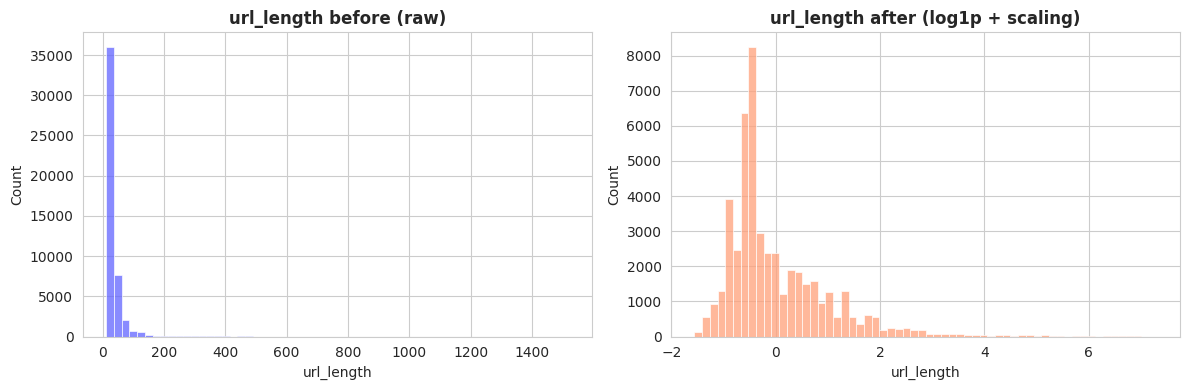

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_train['url_length'], bins=60, ax=axes[0], color='#6164ff')
axes[0].set_title('url_length before (raw)', fontweight='bold')
sns.histplot(X_train_p['url_length'], bins=60, ax=axes[1], color='#FFA07A')
axes[1].set_title('url_length after (log1p + scaling)', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight / Observation:**
* Before: almost all URLs are squeezed into the first few bins, while a few extreme values (over 1,000 characters in the training set) stretch the axis.
* After: the bulk of the URLs is spread over a readable range and the tail is short, which is what scale-sensitive models need. No row was removed to achieve this.

## 8.6 Verifying the transformation

In [35]:
print("Remaining NaN  -> train:", int(X_train_p.isnull().sum().sum()), "| test:", int(X_test_p.isnull().sum().sum()))
print("\nMean / std of the scaled columns (fitted on train, so train should be ~0 / ~1):")
scaled_cols = log_cols + plain_cols
display(X_train_p[scaled_cols].agg(['mean', 'std']).T.round(3))

Remaining NaN  -> train: 0 | test: 0

Mean / std of the scaled columns (fitted on train, so train should be ~0 / ~1):


,mean,std
num_eq,-0.0,1.0
url_length,-0.0,1.0
num_hyphens,0.0,1.0
num_question_mark,0.0,1.0
num_dots,-0.0,1.0
ratio_digits_host,-0.0,1.0
ttl,-0.0,1.0
num_www,-0.0,1.0
ratio_digits_url,-0.0,1.0
length_hostname,0.0,1.0


## 8.7 Rows with identical feature values

Once `url` is removed, different URLs can end up with the **same feature values**, because most features are small integers or 0/1 flags. We check how common this is and whether it hides contradictions.

In [36]:
feature_cols = X_train_p.columns.tolist()

dup_train = X_train_p.duplicated().sum()
dup_test = X_test_p.duplicated().sum()
print("Train rows that repeat an earlier row's feature values:", dup_train, f"({dup_train / len(X_train_p):.1%})")
print("Test rows that repeat an earlier row's feature values :", dup_test, f"({dup_test / len(X_test_p):.1%})")

all_p = pd.concat([X_train_p.assign(target=y_train.values), X_test_p.assign(target=y_test.values)])
per_vector = all_p.groupby(feature_cols, dropna=False)['target'].agg(['nunique', 'size'])
conflicting = per_vector[per_vector['nunique'] > 1]
print("\nDistinct feature vectors:", len(per_vector))
print("Vectors that appear with BOTH labels:", len(conflicting), "| rows involved:", int(conflicting['size'].sum()))

twin = X_test_p.merge(X_train_p.drop_duplicates(), on=feature_cols, how='left', indicator=True)['_merge'].eq('both')
print("\nTest rows whose exact feature vector also exists in train:", int(twin.sum()), f"({twin.mean():.1%})")

Train rows that repeat an earlier row's feature values: 8282 (17.3%)
Test rows that repeat an earlier row's feature values : 196 (1.6%)

Distinct feature vectors: 50757
Vectors that appear with BOTH labels: 6 | rows involved: 16

Test rows whose exact feature vector also exists in train: 771 (6.4%)


**Insight / Observation:**
* About **17% of the training rows repeat the feature values of another row**. They are different URLs (different pages), so they are *not* duplicates in the sense of Section 7.2. It is normal for low-cardinality tabular data, for example many bare homepages with the same length and the same DNS profile.
* Only **6 feature vectors (16 rows) appear with both labels**. That is a tiny amount of unavoidable label noise.
* **6.4% of test rows have an exact feature twin in train.** The twin almost always carries the same label, so this makes test scores slightly optimistic. It is a property of the feature set, not an error we can clean.

**Decision:** keep these rows. Removing them would change the true class distribution and delete real examples of common URL patterns. It is documented so results can be read with the right caution.

## 8.8 Saving the outputs

In [37]:
train_out = X_train_p.assign(target=y_train.values)
test_out = X_test_p.assign(target=y_test.values)
train_out.to_csv("output/preprocessed_train.csv", index=False)
test_out.to_csv("output/preprocessed_test.csv", index=False)
joblib.dump(preprocessor, "output/preprocessor.joblib")
print("Saved: output/preprocessed_train.csv, output/preprocessed_test.csv, output/preprocessor.joblib")

Saved: output/preprocessed_train.csv, output/preprocessed_test.csv, output/preprocessor.joblib


<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Final Dataset Inspection
</div>

# 9. Final Dataset Inspection

In [38]:
print("Final TRAIN:", train_out.shape, "| Final TEST:", test_out.shape)
print("Columns:", train_out.columns.tolist())
print("\nNulls  -> train:", int(train_out.isnull().sum().sum()), "| test:", int(test_out.isnull().sum().sum()))
print("\nData types:")
print(train_out.dtypes.value_counts())
train_out.head()

Final TRAIN: (47875, 20) | Final TEST: (11970, 20)
Columns: ['num_eq', 'url_length', 'num_hyphens', 'num_question_mark', 'num_dots', 'ratio_digits_host', 'ttl', 'num_www', 'ratio_digits_url', 'length_hostname', 'entropy', 'num_subdomains', 'domain_age', 'num_ips', 'num_name_servers', 'random_domain', 'prefix_suffix', 'dns_resolvable', 'domain_age_unknown', 'target']

Nulls  -> train: 0 | test: 0

Data types:
float64    15
int64       5
Name: count, dtype: int64


,num_eq,url_length,num_hyphens,num_question_mark,num_dots,ratio_digits_host,ttl,num_www,ratio_digits_url,length_hostname,entropy,num_subdomains,domain_age,num_ips,num_name_servers,random_domain,prefix_suffix,dns_resolvable,domain_age_unknown,target
0,-0.2229,-1.060662,-0.507949,-0.245063,-0.823904,-0.345044,1.348711,-0.334547,-0.520919,-1.027966,-1.122967,-0.779728,0.020002,-0.660628,0.416405,0,0,1,1,0
1,-0.2229,-0.418595,-0.507949,-0.245063,-0.823904,-0.345044,-0.109473,-0.334547,1.085862,-2.165618,0.075161,-0.779728,-0.225430,-0.660628,2.599672,1,0,1,0,1
2,-0.2229,1.256176,2.844818,-0.245063,0.604340,-0.345044,-0.109473,-0.334547,-0.520919,0.202981,0.356341,0.939494,1.371262,2.988988,0.416405,0,0,1,0,1
3,-0.2229,-0.497838,-0.507949,-0.245063,-0.823904,-0.345044,-0.109473,-0.334547,2.639662,-1.514381,-0.332018,-0.779728,0.020002,0.069295,2.599672,0,0,1,0,1
4,-0.2229,-0.954238,-0.507949,-0.245063,-0.823904,-0.345044,1.348711,-0.334547,-0.520919,-0.824042,-1.394181,-0.779728,0.020002,-0.660628,0.416405,0,0,1,1,0


In [39]:
class_check = pd.DataFrame({
    'train_rows': [(y_train == 0).sum(), (y_train == 1).sum()],
    'train_%': [(y_train == 0).mean() * 100, (y_train == 1).mean() * 100],
    'test_rows': [(y_test == 0).sum(), (y_test == 1).sum()],
    'test_%': [(y_test == 0).mean() * 100, (y_test == 1).mean() * 100],
}, index=['legitimate (0)', 'phishing (1)']).round(1)
class_check

,train_rows,train_%,test_rows,test_%
legitimate (0),22685,47.4,5672,47.4
phishing (1),25190,52.6,6298,52.6


In [40]:
data_info(train_out).drop(columns=['Top_10_Unique_Values', 'Duplicates'])

,Name,Data_Type,Nunique_Values,Nulls,Percent_of_Nulls
0,num_eq,float64,25,0,0.0
1,url_length,float64,440,0,0.0
2,num_hyphens,float64,26,0,0.0
3,num_question_mark,float64,5,0,0.0
4,num_dots,float64,18,0,0.0
5,ratio_digits_host,float64,461,0,0.0
6,ttl,float64,392,0,0.0
7,num_www,float64,4,0,0.0
8,ratio_digits_url,float64,1816,0,0.0
9,length_hostname,float64,77,0,0.0


**Insight / Observation:**
* No NaN, every column numeric, `target` is 0/1. Rows with identical feature values do exist (Section 8.7) and are kept on purpose.
* Train and test both keep a class ratio near 47% / 53%, and no host is shared between them.
* The scaled columns have mean about 0 and std about 1 on train. Binary flags keep their 0/1 meaning.

<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Summary of What Was Done
</div>

# 10. Summary of What Was Done

## 10.1 Row / column count after each step (built from the `cleaning_log`)

In [41]:
pd.DataFrame(cleaning_log)

,Step,Rows,Columns
0,Raw data loaded,60000,20
1,Dropped 2 rows with NaN,59998,20
2,Removed duplicate URLs (149) and conflicting pairs (4 rows),59845,20
3,"Replaced -1 by NaN (domain_age, ttl) + added domain_age_unknown",59845,21
4,Converted 3 float columns to int,59845,21


## 10.2 What changed and why

| # | Action | Reason |
| :-: | :--- | :--- |
| 1 | Used `merged_features_final.xlsx`; ignored the 94k file | The 34,209 extra rows have no features at all |
| 2 | Dropped 2 rows with NaN in all DNS/WHOIS columns | 0.003% of data; imputing five columns would be invention |
| 3 | Removed 149 duplicate URLs, and both rows of 2 conflicting pairs | Duplicates inflate test scores; conflicting labels cannot both be right |
| 4 | `-1` -> NaN in `domain_age` and `ttl` | `-1` is a placeholder, not an age or TTL |
| 5 | Added `domain_age_unknown` | Unknown age is more common in phishing (38% vs 23%), so it carries signal |
| 6 | Converted `dns_resolvable`, `num_ips`, `num_name_servers` to int | They were float only because of NaN |
| 7 | Kept 7 rows with garbled URL text and the 21 URLs > 1000 chars | Numeric features are correct; long URLs are genuine phishing behaviour |
| 8 | Target: phishing = 1, legitimate = 0 | Phishing is the positive class, matches project convention |
| 9 | Stratified, host-grouped 80/20 split | Same host rows are near-identical, so a random split would leak |
| 10 | `log1p` on skewed columns, median imputation, standard scaling; binary flags untouched | Tames heavy tails, removes remaining NaN, puts features on one scale. All fitted on train only |
| 11 | Kept rows with identical feature values (17% of train) | They are different URLs; only 16 rows have contradicting labels (Section 8.7) |

## 10.3 What was NOT fixed - things to keep in mind

1. **The structural shortcut (Section 6.6).** Legitimate = bare homepages, phishing = mostly full links. `num_question_mark` and `num_eq` are 0 for every legitimate row, and `url_length` and `entropy` are softer versions of the same effect. Expect **inflated scores** on this dataset. Recommended next steps: run the model with and without these features (`DROP_SHORTCUT_FEATURES`), and evaluate on the team's own freshly collected URLs, including legitimate URLs *with paths*.
2. **`domain_age` for shared platforms (Section 6.7).** For hosts like `docs.google.com` it is the platform's age. Fixing it needs new lookups.
3. **Same-host rows and feature twins.** The group-aware split protects the test set from shared hosts, but the model can still learn host-specific patterns from very frequent hosts, and 6.4% of test rows have an exact feature twin in train (Section 8.7). Read test scores with that in mind.
4. **Not done on purpose (out of scope):** EDA, feature engineering, feature selection, modelling, evaluation.

## 10.4 Files produced (`output/` folder)

| File | Use it for |
| :--- | :--- |
| `cleaned_dataset.csv` | Tree models (XGBoost handles NaN); contains `url` and text `label` |
| `preprocessed_train.csv` / `preprocessed_test.csv` | Scaled, imputed, ready for any model; last column is `target` |
| `preprocessor.joblib` | The fitted pipeline, to transform new URLs with the same rules |

In [2]:
import joblib

preprocessor = joblib.load("preprocessor.joblib")

preprocessor

,transformers,"[('log_numeric', ...), ('plain_numeric', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,func,<ufunc 'log1p'>
,inverse_func,None
,validate,False
